#  30-Day Hospital Readmission in Diabetic Patients
## A Distributed Machine Learning Approach - Apache Spark MLlib

**Course:** Big Data Analytics and Text Mining - Module 2  
**University:** Università di Bologna - MSc Artificial Intelligence  

---

## Library Versions

| Library | Version |
|---|---|
| PySpark | 3.5.x |
| Python | 3.10+ |
| pandas | 2.0.x |
| matplotlib | 3.7.x |
| seaborn | 0.12.x |
| scikit-learn | 1.3.x |
| xgboost | 2.0.x |

---

## Dataset
- **Source:** UCI Machine Learning Repository  
- **Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008  
- **Records:** 101,766 patient visits | **Features:** 50 clinical variables  
- **Reference:** Strack et al. (2014), BioMed Research International

---

## Research Questions
1. Can we reliably predict 30-day readmission from clinical features available at discharge?
2. Which features carry the most predictive weight?
3. Does model performance differ significantly across patient age groups?
4. Does feature engineering improve predictive performance?
5. How does class weighting affect results on imbalanced data?

---

## ML Algorithms

| # | Algorithm | Imbalance Strategy | Notes |
|---|---|---|---|
| 1 | Decision Tree | Class Weights | Most interpretable - clinical rules |
| 2 | Random Forest | Class Weights | Feature importance ranking |
| 3 | XGBoost | Class Weights | Best overall discriminator |


In [1]:
# Core Spark
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, udf, rank, lit
from pyspark.sql.types import StringType, IntegerType

# Spark ML
from pyspark.ml.feature import RFormula
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)
from pyspark.ml.functions import vector_to_array

# External
from sklearn.metrics import roc_curve, auc as sk_auc
from functools import reduce as fred
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")


All imports successful


In [2]:
spark = SparkSession.builder \
    .appName("DiabetesReadmission") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")



In [3]:
import urllib.request, zipfile, os

URL = ("https://archive.ics.uci.edu/static/public/296/"
       "diabetes+130-us+hospitals+for+years+1999-2008.zip")

if not os.path.exists("diabetic_data.csv"):
    print("Downloading dataset from UCI...")
    urllib.request.urlretrieve(URL, "diabetes.zip")
    with zipfile.ZipFile("diabetes.zip", "r") as z:
        z.extractall(".")
    print("Downloaded")
else:
    print("Already exists")

df = spark.read.csv("diabetic_data.csv", header=True, inferSchema=True)
df = df.toDF(*[c.strip() for c in df.columns])
print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")


Downloaded
Rows    : 101,766
Columns : 50


In [4]:
# Check missing values (represented as '?')
print("Missing value check (? counts per column):")
for column, dtype in df.dtypes:
    if dtype == "string":
        count = df.filter(col(column) == "?").count()
        if count > 0:
            print(f"  {column:<30}: {count:,}")


Missing value check (? counts per column):
  race                          : 2,273
  weight                        : 98,569
  payer_code                    : 40,256
  medical_specialty             : 49,949
  diag_1                        : 21
  diag_2                        : 358
  diag_3                        : 1,423


## Preprocessing

Ten preprocessing steps applied in sequence:

1. Replace `?` with null
2. Keep only first visit per patient (prevent data leakage between visits)
3. Remove deceased / hospice patients (cannot be readmitted - distorts class 0)
4. Drop useless columns (IDs, near-zero-variance medications, high-missingness)
5. Clean age column -> integer midpoints
6. Fix race and gender
7. Map ICD-9 diagnosis codes to 9 clinical categories
8. Binarize medication columns (No=0, any use=1)
9. Cast ordinal ID columns to string (prevent magnitude interpretation)
10. Create binary target label (readmitted <30 days = 1)


In [5]:
# Step 1: Replace ? with null
df = df.replace("?", None)

# Step 2: Keep only FIRST visit per patient
# Same patient appearing multiple times would cause data leakage
# if their visits are split across train and test sets.
window = Window.partitionBy("patient_nbr").orderBy("encounter_id")
df = df.withColumn("visit_rank", rank().over(window))
df = df.filter(col("visit_rank") == 1).drop("visit_rank")
print(f"After deduplication   : {df.count():,}")

# Step 3: Remove deceased / hospice patients
# Codes 11,19,20,21 = deceased. Codes 13,14 = hospice (end-of-life).
# These patients cannot be readmitted - their non-readmission
# reflects death/end-of-life, not successful diabetes management.
terminal_codes = [11, 13, 14, 19, 20, 21]
df = df.filter(~col("discharge_disposition_id").isin(terminal_codes))
print(f"After removing terminal: {df.count():,}")

# Step 4: Drop useless columns
zero_var_meds = [
    "examide", "citoglipton", "acetohexamide",
    "troglitazone", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]
drop_cols = [
    "encounter_id", "patient_nbr",   # random IDs - no predictive value
    "weight",                          # 97% missing
    "payer_code", "medical_specialty", # high missingness
] + zero_var_meds
df = df.drop(*drop_cols)
print(f"Columns after dropping : {len(df.columns)}")

# Step 5: Clean age - map brackets to integer midpoints
def age_to_midpoint(age_str):
    mapping = {
        "[0-10)":5, "[10-20)":15, "[20-30)":25, "[30-40)":35,
        "[40-50)":45, "[50-60)":55, "[60-70)":65,
        "[70-80)":75, "[80-90)":85, "[90-100)":95
    }
    return mapping.get(age_str, None)

age_udf = udf(age_to_midpoint, IntegerType())
df = df.withColumn("age", age_udf(col("age")))

# Step 6: Fix race and gender
df = df.fillna({"race": "Unknown"})
df = df.filter(col("gender") != "Unknown/Invalid")

# Step 7: Map ICD-9 diagnosis codes to clinical categories
def map_diag(code):
    if code is None: return "Other"
    try:
        c = float(code)
        if 250 <= c < 251:              return "Diabetes"
        elif 390 <= c <= 459 or c==785: return "Circulatory"
        elif 460 <= c <= 519 or c==786: return "Respiratory"
        elif 520 <= c <= 579 or c==787: return "Digestive"
        elif 800 <= c <= 999:           return "Injury"
        elif 710 <= c <= 739:           return "Musculoskeletal"
        elif 580 <= c <= 629 or c==788: return "Genitourinary"
        elif 140 <= c <= 239:           return "Neoplasms"
        else:                           return "Other"
    except:
        return "Injury" if str(code).startswith("E") else "Other"

map_diag_udf = udf(map_diag, StringType())
for dc in ["diag_1", "diag_2", "diag_3"]:
    df = df.withColumn(dc, map_diag_udf(col(dc)))

# Step 8: Binarize medication columns
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "glipizide", "glyburide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "tolazamide",
    "tolbutamide", "insulin", "glyburide-metformin", "glipizide-metformin"
]
for med in medication_cols:
    df = df.withColumn(med, when(col(med) == "No", 0).otherwise(1))

# Step 9: Cast ID columns to string (categorical, not ordinal)
for ic in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df = df.withColumn(ic, col(ic).cast("string"))

# Step 10: Create binary label
# <30 days = 1 (readmitted - minority, clinically critical class)
# >30 days or NO = 0 (not readmitted - majority class)
df = df.withColumn("label", when(col("readmitted") == "<30", 1).otherwise(0))
df = df.drop("readmitted")

print(f"\nFinal rows    : {df.count():,}")
print(f"Final columns : {len(df.columns)}")
print("\nClass distribution:")
df.groupBy("label").count().show()


After deduplication   : 71,518
After removing terminal: 69,973
Columns after dropping : 38

Final rows    : 69,970
Final columns : 38

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0|63693|
|    1| 6277|
+-----+-----+



## Feature Engineering

14 new clinically motivated features created from existing columns.

These features capture patterns that raw columns cannot express individually:
- **Treatment intensity** - how aggressively was the patient being treated?
- **Prior burden** - how many times has this patient needed hospital care before?
- **Disease complexity** - how many different conditions does this patient have?
- **Medication management** - is diabetes well controlled (HbA1c tested/abnormal)?
- **High-risk combinations** - diabetes + circulatory disease = worst outcome


In [6]:
# Feature 1: Medication intensity per day
# Captures how intensively the patient was treated during their stay
df = df.withColumn("medications_per_day",
    col("num_medications") / col("time_in_hospital"))

# Feature 2-3: Multi-disease burden
df = df.withColumn("multiple_diseases",
    when((col("diag_1") != col("diag_2")) &
         (col("diag_2") != col("diag_3")) &
         (col("diag_1") != col("diag_3")), 1).otherwise(0))

df = df.withColumn("has_diabetes_plus_other",
    when((col("diag_1") == "Diabetes") |
         (col("diag_2") == "Diabetes") |
         (col("diag_3") == "Diabetes"), 1).otherwise(0))

# Feature 4-5: Prior hospitalisation burden
# number_inpatient was the #1 predictor in Random Forest
df = df.withColumn("prior_hospital_burden",
    col("number_inpatient") +
    col("number_emergency") +
    col("number_outpatient"))

df = df.withColumn("has_prior_inpatient",
    when(col("number_inpatient") > 0, 1).otherwise(0))

# Feature 6: Lab test intensity
df = df.withColumn("lab_intensity",
    col("num_lab_procedures") / col("time_in_hospital"))

# Feature 7-8: HbA1c management quality
# Strack et al. (2014) found HbA1c measurement associated with
# reduced readmission - doctors who tested it managed patients better
df = df.withColumn("A1C_tested",
    when(col("A1Cresult") != "None", 1).otherwise(0))
df = df.withColumn("A1C_abnormal",
    when(col("A1Cresult").isin(">7", ">8"), 1).otherwise(0))

# Feature 9-10: Circulatory comorbidity
# Diabetes + heart disease = highest readmission risk combination
df = df.withColumn("has_circulatory",
    when(col("diag_1") == "Circulatory", 1).otherwise(0))
df = df.withColumn("diabetes_circulatory",
    when(((col("diag_1")=="Diabetes")|(col("diag_2")=="Diabetes")|
          (col("diag_3")=="Diabetes")) &
         ((col("diag_1")=="Circulatory")|(col("diag_2")=="Circulatory")|
          (col("diag_3")=="Circulatory")), 1).otherwise(0))

# Feature 11-12: High-risk age indicators
df = df.withColumn("high_risk_age",
    when(col("age") >= 75, 1).otherwise(0))
df = df.withColumn("elderly_high_meds",
    when((col("age") >= 65) &
         (col("num_medications") > 15), 1).otherwise(0))

# Feature 13-14: Active medication burden
df = df.withColumn("active_diabetes_meds",
    fred(lambda a, b: a + b, [col(c) for c in medication_cols]))
df = df.withColumn("poly_pharmacy",
    when(col("active_diabetes_meds") >= 3, 1).otherwise(0))

print(f"Features added : 14")
print(f"Total columns  : {len(df.columns)} ({len(df.columns)-1} features + label)")

# Verify new features look sensible
df.select("medications_per_day","prior_hospital_burden",
          "A1C_tested","poly_pharmacy","label").show(5)


Features added : 14
Total columns  : 52 (51 features + label)
+-------------------+---------------------+----------+-------------+-----+
|medications_per_day|prior_hospital_burden|A1C_tested|poly_pharmacy|label|
+-------------------+---------------------+----------+-------------+-----+
|              4.125|                    0|         0|            1|    1|
|                5.5|                    0|         0|            0|    0|
|               5.75|                    0|         1|            0|    0|
| 2.1666666666666665|                    1|         0|            0|    0|
| 1.7777777777777777|                    0|         0|            0|    0|
+-------------------+---------------------+----------+-------------+-----+
only showing top 5 rows


## Exploratory Data Analysis


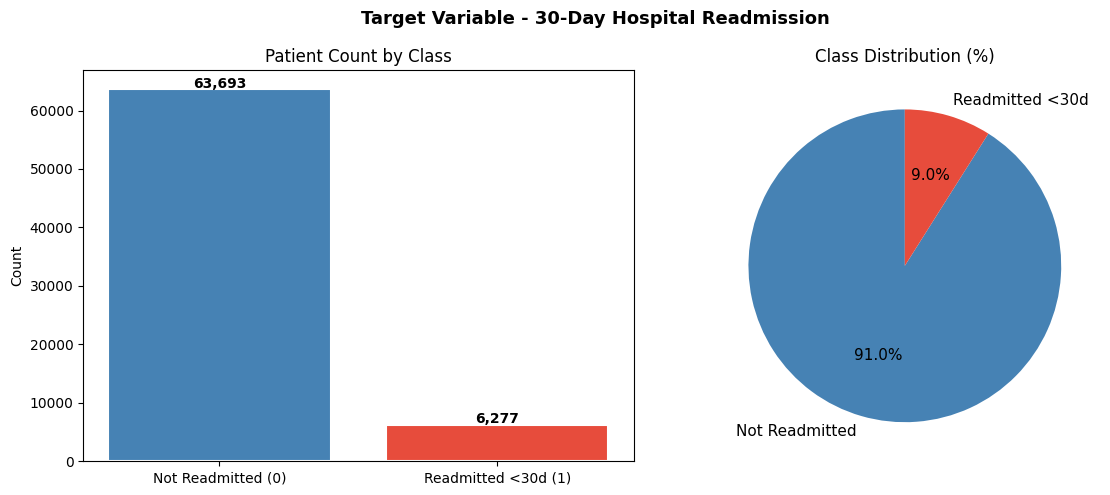

Class imbalance ratio : 10.1:1
-> Model will need class weighting to handle this imbalance


In [7]:
sample_pd = df.sample(fraction=0.4, seed=42).toPandas()

# Plot 1: Class Distribution
lc = df.groupBy("label").count().toPandas().sort_values("label")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable - 30-Day Hospital Readmission",
             fontsize=13, fontweight="bold")

axes[0].bar(["Not Readmitted (0)", "Readmitted <30d (1)"],
            lc["count"],
            color=["steelblue", "#E74C3C"], edgecolor="white", linewidth=1.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Patient Count by Class")
for i, v in enumerate(lc["count"]):
    axes[0].text(i, v+200, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(lc["count"],
            labels=["Not Readmitted", "Readmitted <30d"],
            colors=["steelblue", "#E74C3C"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = lc["count"].iloc[0] / lc["count"].iloc[1]
print(f"Class imbalance ratio : {ratio:.1f}:1")
print("-> Model will need class weighting to handle this imbalance")
